# Exploratory Data Analysis

In [5]:
import pandas as pd
import numpy as np

In [6]:
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

In [10]:
df_train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [12]:
df_train['loan_paid_back'].value_counts(normalize=True)
# 80% vs. 20% imbalance verified

loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

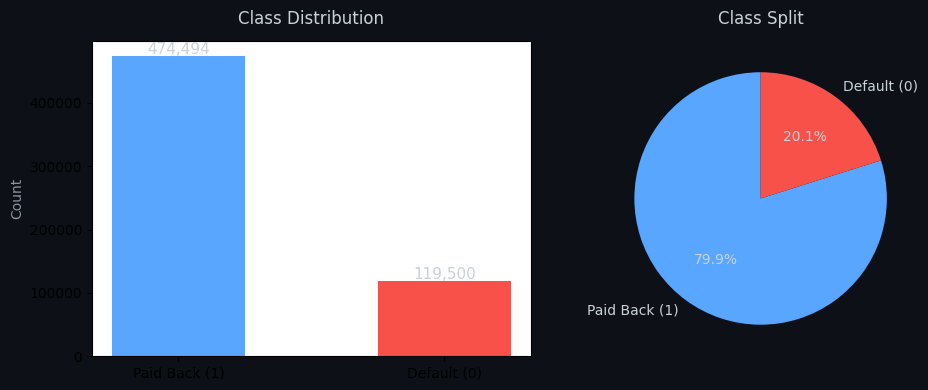

Paid back : 474,494  (79.9%)
Default   : 119,500  (20.1%)
Ratio     : 4.0:1


In [15]:
import matplotlib.pyplot as plt

counts = df_train['loan_paid_back'].value_counts()
labels = ['Paid Back (1)', 'Default (0)']
colors = ['#58a6ff', '#f85149']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor('#0d1117')

# Bar chart
axes[0].bar(labels, [counts[1], counts[0]], color=colors, width=0.5)
axes[0].set_title('Class Distribution', color='#c9d1d9', pad=12)
axes[0].set_ylabel('Count', color='#8b949e')
for i, v in enumerate([counts[1], counts[0]]):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', color='#c9d1d9', fontsize=11)

# Pie chart
axes[1].pie(
    [counts[1], counts[0]],
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    textprops={'color': '#c9d1d9'},
    startangle=90
)
axes[1].set_title('Class Split', color='#c9d1d9', pad=12)

plt.tight_layout()
plt.show()

print(f"Paid back : {counts[1]:,}  ({counts[1]/len(df_train)*100:.1f}%)")
print(f"Default   : {counts[0]:,}  ({counts[0]/len(df_train)*100:.1f}%)")
print(f"Ratio     : {counts[1]/counts[0]:.1f}:1")

In [17]:
df_train.dtypes

id                        int64
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                      str
marital_status              str
education_level             str
employment_status           str
loan_purpose                str
grade_subgrade              str
loan_paid_back          float64
dtype: object

In [18]:
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_train.select_dtypes(include=['object']).columns.tolist()

num_cols = [c for c in num_cols if c not in ['id','loan_paid_back']]
cat_cls = [c for c in cat_cols if c not in ['id']]

print(f"Numerical  ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

Numerical  (5): ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
Categorical (6): ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']


C:\Users\jackj\AppData\Local\Temp\ipykernel_23064\2383086111.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_train.select_dtypes(include=['object']).columns.tolist()


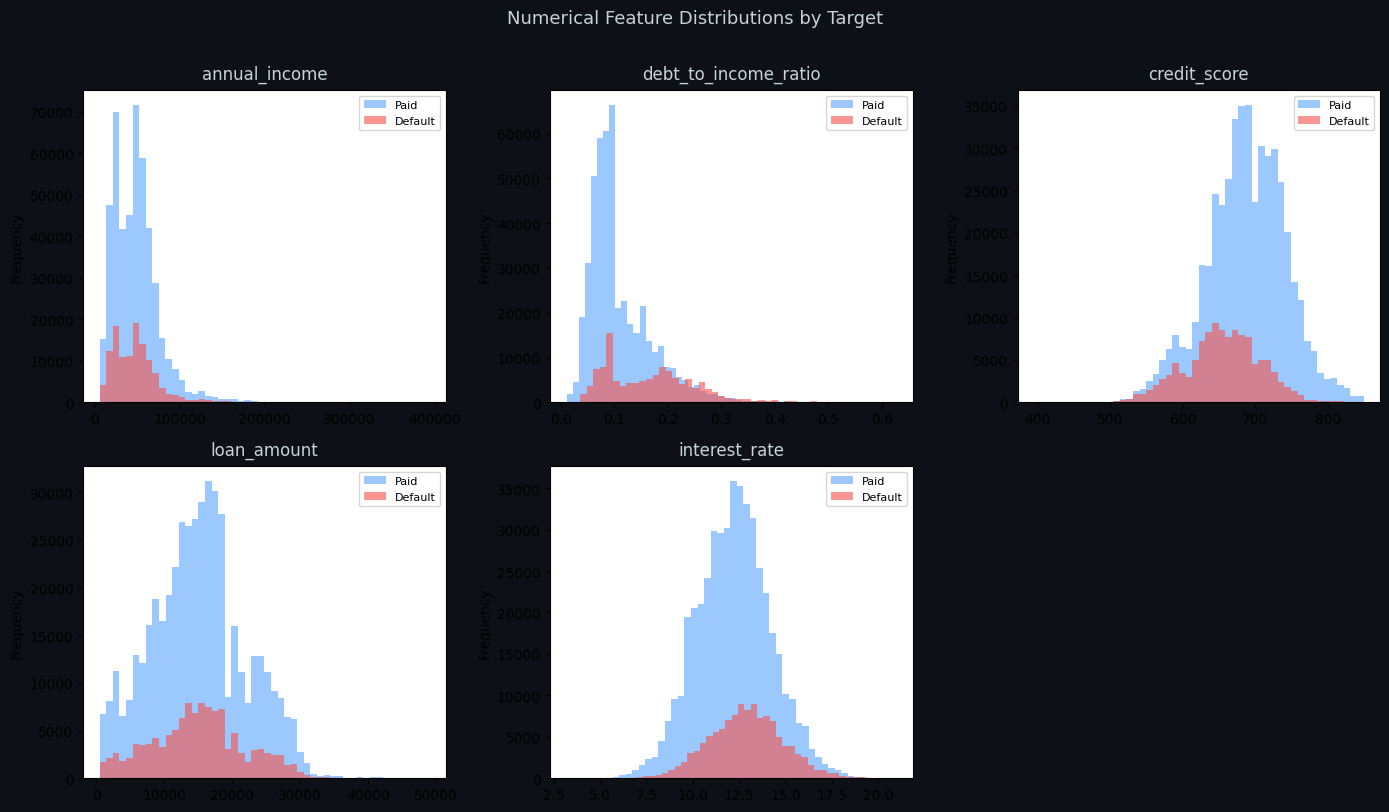

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df_train[df_train['loan_paid_back']==1][col].plot.hist(ax=ax, bins=50, alpha=0.6, color='#58a6ff', label='Paid')
    df_train[df_train['loan_paid_back']==0][col].plot.hist(ax=ax, bins=50, alpha=0.6, color='#f85149', label='Default')
    ax.set_title(col, color='#c9d1d9', pad=8)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Target', color='#c9d1d9', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
cat_cols

['gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade']

In [23]:
df_train[cat_cols[0]].value_counts()


gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64

In [24]:
pd.DataFrame({
    'unique_values': df_train[cat_cols].nunique(),
    'sample_values': [df_train[col].unique()[:3].tolist() for col in cat_cols]
}).sort_values('unique_values', ascending=False)

,unique_values,sample_values
grade_subgrade,30,"[C3, D3, C5]"
loan_purpose,8,"[Other, Debt consolidation, Home]"
employment_status,5,"[Self-employed, Employed, Unemployed]"
education_level,5,"[High School, Master's, Bachelor's]"
marital_status,4,"[Single, Married, Divorced]"
gender,3,"[Female, Male, Other]"


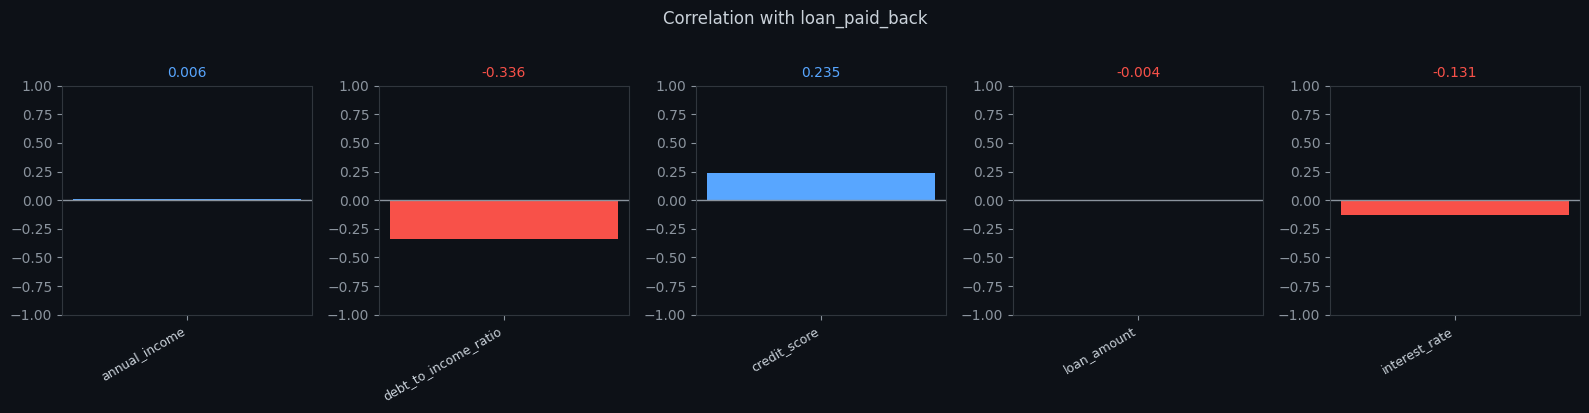

In [30]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4))
fig.patch.set_facecolor('#0d1117')

for i, col in enumerate(num_cols):
    corr_val = df_train[col].corr(df_train['loan_paid_back'])
    color = '#58a6ff' if corr_val >= 0 else '#f85149'
    
    ax = axes[i]
    ax.set_facecolor('#0d1117')
    ax.bar([col], [corr_val], color=color, width=0.5)
    ax.set_ylim(-1, 1)
    ax.axhline(0, color='#8b949e', linewidth=1)
    ax.set_title(f'{corr_val:.3f}', color=color, pad=6, fontsize=10)
    ax.tick_params(colors='#8b949e')
    ax.set_xticks([0])
    ax.set_xticklabels([col], rotation=30, ha='right', fontsize=9, color='#c9d1d9')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

plt.suptitle('Correlation with loan_paid_back', color='#c9d1d9', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

No missing values found.


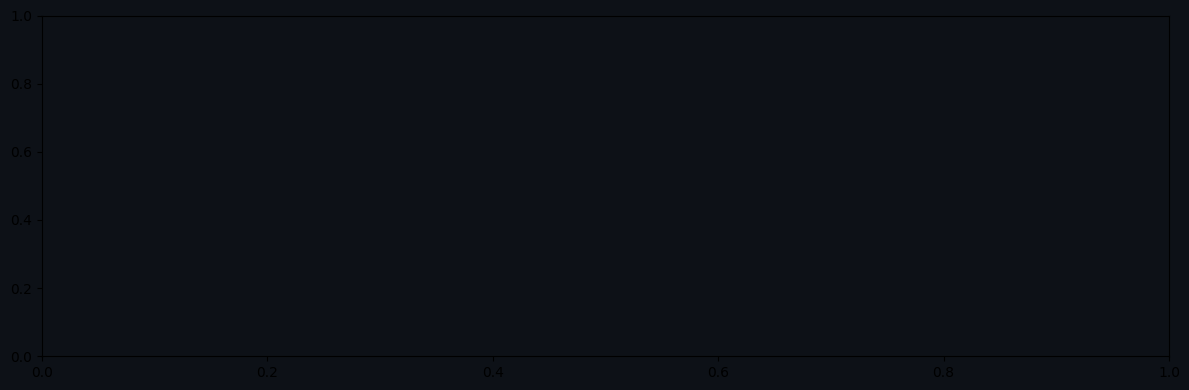

In [31]:
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

missing = df_train.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("No missing values found.")
else:
    bars = ax.bar(missing.index, missing.values, color='#f85149', width=0.5)
    ax.set_ylabel('Missing %', color='#8b949e')
    ax.set_title('Missing Values by Feature', color='#c9d1d9', pad=12)
    ax.tick_params(colors='#8b949e')
    ax.set_xticks(range(len(missing)))
    ax.set_xticklabels(missing.index, rotation=30, ha='right', color='#c9d1d9')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    for bar, val in zip(bars, missing.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', color='#c9d1d9', fontsize=9)

plt.tight_layout()
plt.show()

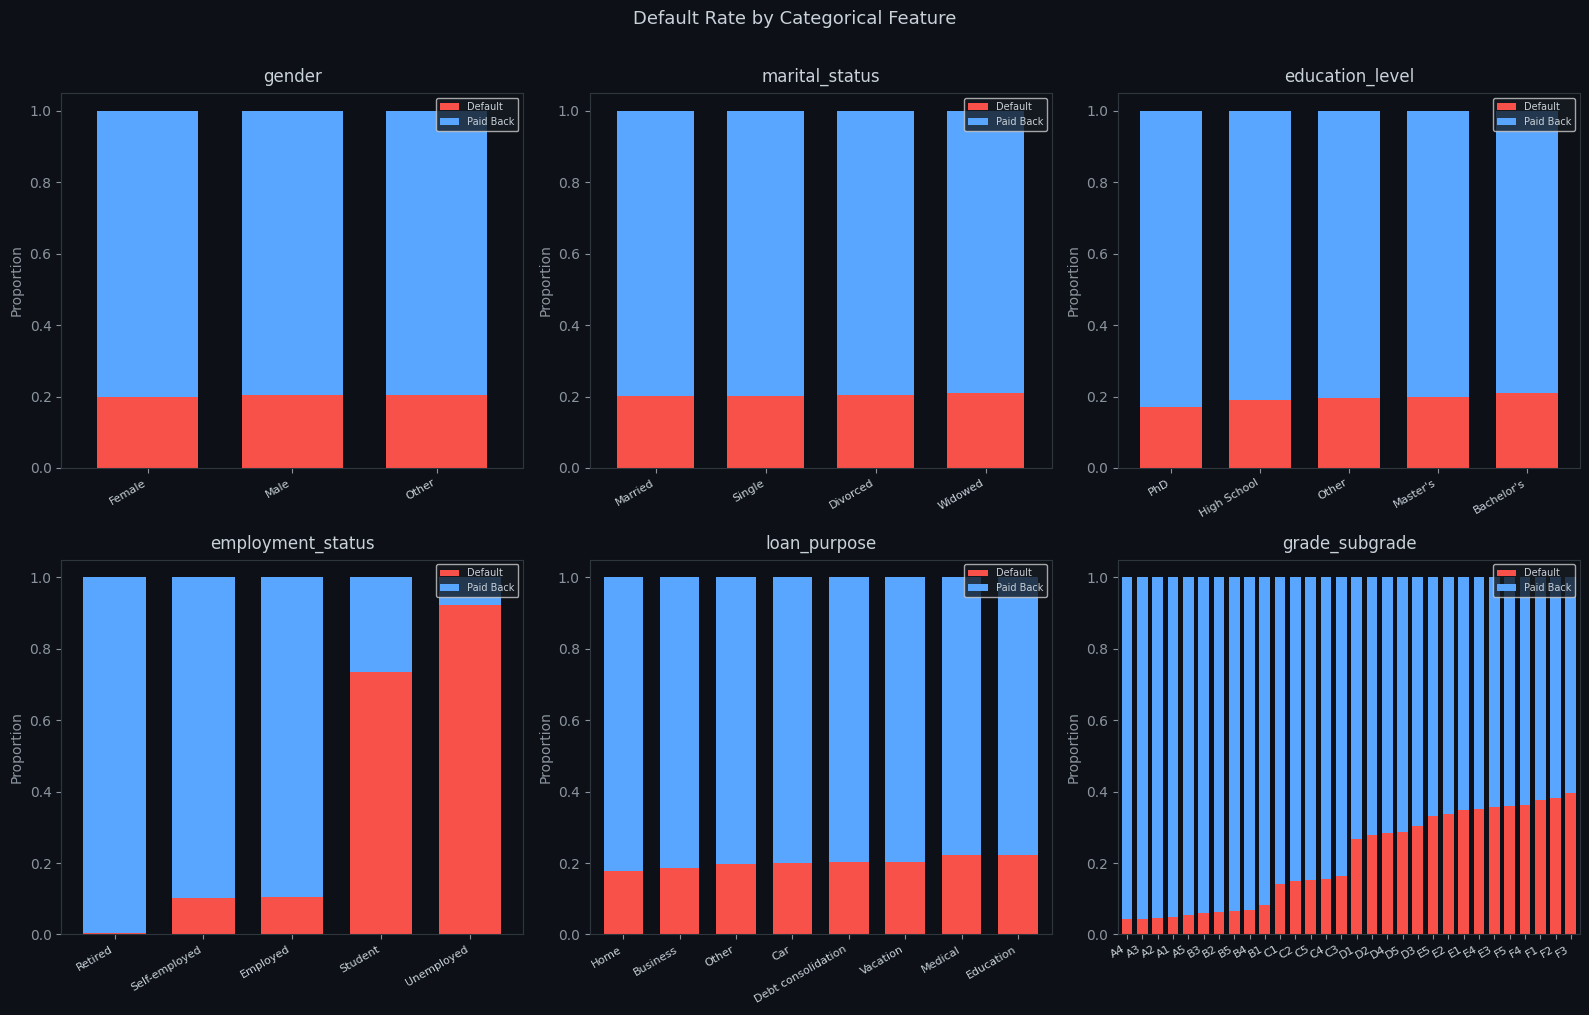

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    ax.set_facecolor('#0d1117')

    group = (df_train.groupby(col)['loan_paid_back']
             .value_counts(normalize=True)
             .unstack()
             .sort_values(0))  # sort by default rate ascending

    group.plot(kind='bar', ax=ax, stacked=True,
               color=['#f85149', '#58a6ff'],
               width=0.7, edgecolor='none')

    ax.set_title(col, color='#c9d1d9', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Proportion', color='#8b949e')
    ax.tick_params(colors='#8b949e')
    ax.set_xticklabels(group.index, rotation=30, ha='right', color='#c9d1d9', fontsize=8)
    ax.legend(['Default', 'Paid Back'], facecolor='#161b22', labelcolor='#c9d1d9', fontsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Default Rate by Categorical Feature', color='#c9d1d9', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [34]:
df_train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


## Preprocessing

In [63]:
from sklearn.preprocessing import OrdinalEncoder
from category_encoders import TargetEncoder

df_train_processed = df_train.copy()
df_test_processed  = df_test.copy()

# ── Ordinal: grade_subgrade
grade_order = [f'{l}{n}' for l in 'ABCDEF' for n in range(1, 6)]
oe_grade = OrdinalEncoder(categories=[grade_order], handle_unknown='use_encoded_value', unknown_value=-1)
df_train_processed['grade_subgrade'] = oe_grade.fit_transform(df_train_processed[['grade_subgrade']])
df_test_processed['grade_subgrade']  = oe_grade.transform(df_test_processed[['grade_subgrade']])

# ── Ordinal: education_level
edu_order = [['High School', "Bachelor's", "Master's", 'PhD']]
oe_edu = OrdinalEncoder(categories=edu_order, handle_unknown='use_encoded_value', unknown_value=-1)
df_train_processed['education_level'] = oe_edu.fit_transform(df_train_processed[['education_level']])
df_test_processed['education_level']  = oe_edu.transform(df_test_processed[['education_level']])

# ── Target encoding: loan_purpose, employment_status
# Must be fit on train only to avoid leakage
te = TargetEncoder(cols=['loan_purpose', 'employment_status'], smoothing=10)
df_train_processed[['loan_purpose', 'employment_status']] = te.fit_transform(
    df_train_processed[['loan_purpose', 'employment_status']],
    df_train_processed[TARGET_COL]
)
df_test_processed[['loan_purpose', 'employment_status']] = te.transform(
    df_test_processed[['loan_purpose', 'employment_status']]
)

# ── Label: gender, marital_status
le = LabelEncoder()
for col in ['gender', 'marital_status']:
    combined = pd.concat([df_train_processed[col], df_test_processed[col]])
    le.fit(combined)
    df_train_processed[col] = le.transform(df_train_processed[col])
    df_test_processed[col]  = le.transform(df_test_processed[col])

df_train_processed.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,0,2,0.0,0.898457,0.802377,12.0,1.0
1,1,22108.02,0.166,636,4593.10,12.92,1,1,2.0,0.894145,0.796911,17.0,0.0
2,2,49566.20,0.097,694,17005.15,9.76,1,2,0.0,0.894145,0.796911,14.0,1.0
3,3,46858.25,0.065,533,4682.48,16.10,0,2,0.0,0.894145,0.796911,25.0,1.0
4,4,25496.70,0.053,665,12184.43,10.21,1,1,0.0,0.894145,0.802377,15.0,1.0


## Feature Engineering

In [64]:
def engineer_features(df):
    df = df.copy()
    
    # ── Ratio features
    df['loan_to_income']         = df['loan_amount'] / (df['annual_income'] + 1)
    df['interest_burden']        = df['loan_amount'] * df['interest_rate'] / 100
    df['implied_total_debt']     = df['debt_to_income_ratio'] * df['annual_income']
    df['loan_to_credit']         = df['loan_amount'] / (df['credit_score'] + 1)

    # # ── Credit score bands (standard industry bands)
    # df['credit_band'] = pd.cut(
    #     df['credit_score'],
    #     bins=[0, 580, 669, 739, 799, 900],
    #     labels=[0, 1, 2, 3, 4]
    # ).astype(int)

    # # ── Interest rate bands
    # df['interest_band'] = pd.cut(
    #     df['interest_rate'],
    #     bins=[0, 8, 13, 18, 100],
    #     labels=[0, 1, 2, 3]
    # ).astype(int)

    # ── Split grade_subgrade into letter and number
#     df['grade_letter'] = df['grade_subgrade'].astype(str).str[0]
#     df['grade_number'] = pd.to_numeric(
#     df['grade_subgrade'].astype(str).str[1], errors='coerce'
# ).fillna(0).astype(int)

    return df


df_train_fe = engineer_features(df_train_processed)
df_test_fe  = engineer_features(df_test_processed)


print(f'Features before: {X.shape[1]}')
print(f'Features after : {df_train_fe.drop(columns=["id", TARGET_COL]).shape[1]}')
df_train_fe.head()

Features before: 11
Features after : 15


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,loan_to_income,interest_burden,implied_total_debt,loan_to_credit
0,0,29367.99,0.084,736,2528.42,13.67,0,2,0.0,0.898457,0.802377,12.0,1.0,0.086091,345.635014,2466.91116,3.430692
1,1,22108.02,0.166,636,4593.10,12.92,1,1,2.0,0.894145,0.796911,17.0,0.0,0.207748,593.428520,3669.93132,7.210518
2,2,49566.20,0.097,694,17005.15,9.76,1,2,0.0,0.894145,0.796911,14.0,1.0,0.343073,1659.702640,4807.92140,24.467842
3,3,46858.25,0.065,533,4682.48,16.10,0,2,0.0,0.894145,0.796911,25.0,1.0,0.099926,753.879280,3045.78625,8.768689
4,4,25496.70,0.053,665,12184.43,10.21,1,1,0.0,0.894145,0.802377,15.0,1.0,0.477864,1244.030303,1351.32510,18.294940


In [66]:
drop_cols = ['gender', 'marital_status']

X_tuned = X_fe.drop(columns=drop_cols)
print(f'Features remaining: {X_tuned.shape[1]}')
print(X_tuned.columns.tolist())

Features remaining: 13
['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_to_income', 'interest_burden', 'implied_total_debt', 'loan_to_credit']


## Train Models

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import numpy as np


TARGET_COL = 'loan_paid_back'

X = df_train_processed.drop(columns=['id', TARGET_COL])
y = df_train_processed[TARGET_COL]

models = {
    #'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'), # this is a baseline, so we use class_weight to help
    'LightGBM':            LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    #'XGBoost':             XGBClassifier(scale_pos_weight=4, random_state=42, eval_metric='auc'),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f'  AUC: {scores.mean():.4f} ± {scores.std():.4f}')

print('\n--- Summary ---')
for name, scores in results.items():
    print(f'{name:<25} {scores.mean():.4f} ± {scores.std():.4f}')


Training LightGBM...
  AUC: 0.9201 ± 0.0011

--- Summary ---
LightGBM                  0.9201 ± 0.0011


In [58]:
X_fe = df_train_fe.drop(columns=['id', TARGET_COL])
y_fe = df_train_fe[TARGET_COL]

scores_fe = cross_val_score(
    LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    X_fe, y_fe, cv=5, scoring='roc_auc', n_jobs=-1
)

print(f'Before FE: 0.9201')
print(f'After FE : {scores_fe.mean():.4f} ± {scores_fe.std():.4f}')

Before FE: 0.9201
After FE : 0.9199 ± 0.0011


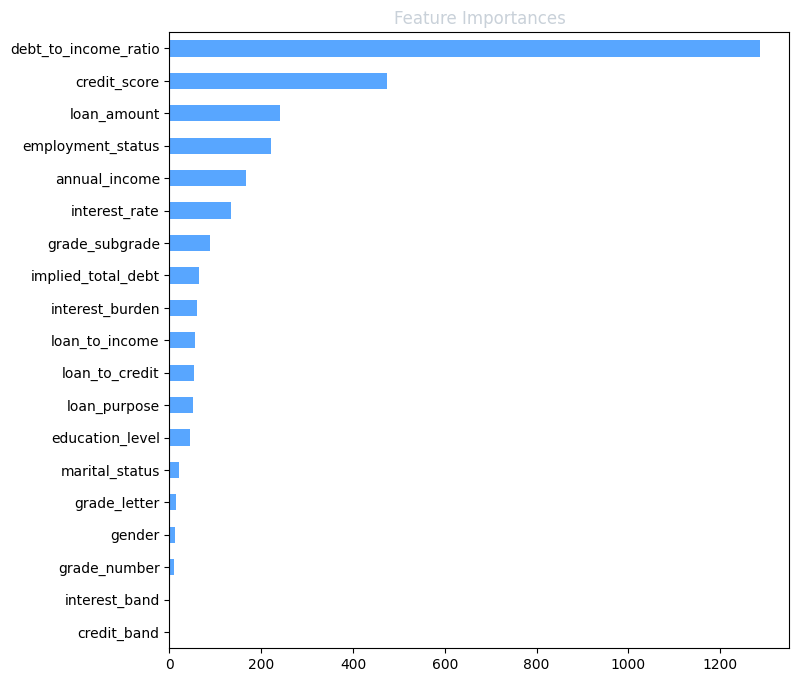

In [46]:
model = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
model.fit(X_fe, y_fe)

feat_imp = pd.Series(model.feature_importances_, index=X_fe.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 8), color='#58a6ff')
plt.title('Feature Importances', color='#c9d1d9')
plt.show()

In [67]:
from sklearn.model_selection import cross_val_predict

# ── Get out-of-fold probability predictions from each model
lgbm_model = LGBMClassifier(**best_params, class_weight='balanced', random_state=42, verbose=-1)
xgb_model  = XGBClassifier(scale_pos_weight=4, random_state=42, eval_metric='auc', n_jobs=-1)

print('Getting LightGBM OOF predictions...')
lgbm_oof = cross_val_predict(lgbm_model, X_tuned, y_fe, cv=5, method='predict_proba', n_jobs=-1)[:, 1]

print('Getting XGBoost OOF predictions...')
xgb_oof  = cross_val_predict(xgb_model, X_tuned, y_fe, cv=5, method='predict_proba', n_jobs=-1)[:, 1]

# ── Evaluate each individually and blended
from sklearn.metrics import roc_auc_score

lgbm_auc  = roc_auc_score(y_fe, lgbm_oof)
xgb_auc   = roc_auc_score(y_fe, xgb_oof)
blend_auc  = roc_auc_score(y_fe, 0.5 * lgbm_oof + 0.5 * xgb_oof)

print(f'\nLightGBM AUC : {lgbm_auc:.4f}')
print(f'XGBoost AUC  : {xgb_auc:.4f}')
print(f'Blend AUC    : {blend_auc:.4f}')

Getting LightGBM OOF predictions...
Getting XGBoost OOF predictions...

LightGBM AUC : 0.9231
XGBoost AUC  : 0.9199
Blend AUC    : 0.9229


## Hyper Parameter Tuning

In [59]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'class_weight': 'balanced',
        'random_state': 42,
        'verbose': -1,
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_tuned, y_fe, cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest AUC  : {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC  : 0.9231
Best params: {'n_estimators': 929, 'max_depth': 3, 'learning_rate': 0.20500355271576148, 'num_leaves': 136, 'min_child_samples': 55, 'subsample': 0.970525603747719, 'colsample_bytree': 0.730946592537135, 'reg_alpha': 0.04488386265135877, 'reg_lambda': 0.028378759246160797}


In [68]:
best_params = study.best_params

final_model = LGBMClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

final_model.fit(X_tuned, y_fe)
print('Model fitted successfully')

Model fitted successfully


In [69]:
X_test = df_test_fe.drop(columns=['id'] + drop_cols)

test_preds = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': df_test['id'],
    'loan_paid_back': test_preds
})

submission.to_csv('../submissions/submission_v1.csv', index=False)
print(submission.head())
print(f'Submission shape: {submission.shape}')

       id  loan_paid_back
0  593994        0.980451
1  593995        0.995844
2  593996        0.921404
3  593997        0.988228
4  593998        0.992149
Submission shape: (254569, 2)


In [70]:
from sklearn.model_selection import StratifiedKFold
from category_encoders import TargetEncoder
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_raw = df_train_processed.drop(columns=['id', TARGET_COL])
y     = df_train_processed[TARGET_COL]
X_test_raw = df_test_processed.drop(columns=['id'])

oof_preds  = np.zeros(len(X_raw))
test_preds = np.zeros(len(X_test_raw))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y)):
    print(f'Fold {fold + 1}/5...')

    X_tr, X_val = X_raw.iloc[train_idx].copy(), X_raw.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_te = X_test_raw.copy()

    # ── Target encoding inside fold (no leakage)
    te = TargetEncoder(cols=['loan_purpose', 'employment_status'], smoothing=10)
    X_tr[['loan_purpose', 'employment_status']] = te.fit_transform(
        X_tr[['loan_purpose', 'employment_status']], y_tr
    )
    X_val[['loan_purpose', 'employment_status']] = te.transform(
        X_val[['loan_purpose', 'employment_status']]
    )
    X_te[['loan_purpose', 'employment_status']] = te.transform(
        X_te[['loan_purpose', 'employment_status']]
    )

    # ── Feature engineering inside fold
    X_tr  = engineer_features(X_tr).drop(columns=drop_cols)
    X_val = engineer_features(X_val).drop(columns=drop_cols)
    X_te  = engineer_features(X_te).drop(columns=drop_cols)

    # ── Train
    model = LGBMClassifier(**best_params, class_weight='balanced', random_state=42, verbose=-1)
    model.fit(X_tr, y_tr)

    # ── Validate
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    # ── Test (average across folds)
    test_preds += model.predict_proba(X_te)[:, 1] / 5

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f'  Fold AUC: {fold_auc:.4f}')

print(f'\nOverall OOF AUC: {roc_auc_score(y, oof_preds):.4f}')

# ── Submission
submission = pd.DataFrame({
    'id':             df_test['id'],
    'loan_paid_back': test_preds
})
submission.to_csv('../submissions/submission_v2.csv', index=False)
print('\nsubmission_v2.csv saved')

Fold 1/5...
  Fold AUC: 0.9240
Fold 2/5...
  Fold AUC: 0.9236
Fold 3/5...
  Fold AUC: 0.9221
Fold 4/5...
  Fold AUC: 0.9231
Fold 5/5...
  Fold AUC: 0.9219

Overall OOF AUC: 0.9229

submission_v2.csv saved
